# Question 3 Random Walk Task

100%|██████████| 1000/1000 [00:00<00:00, 7136.64it/s]


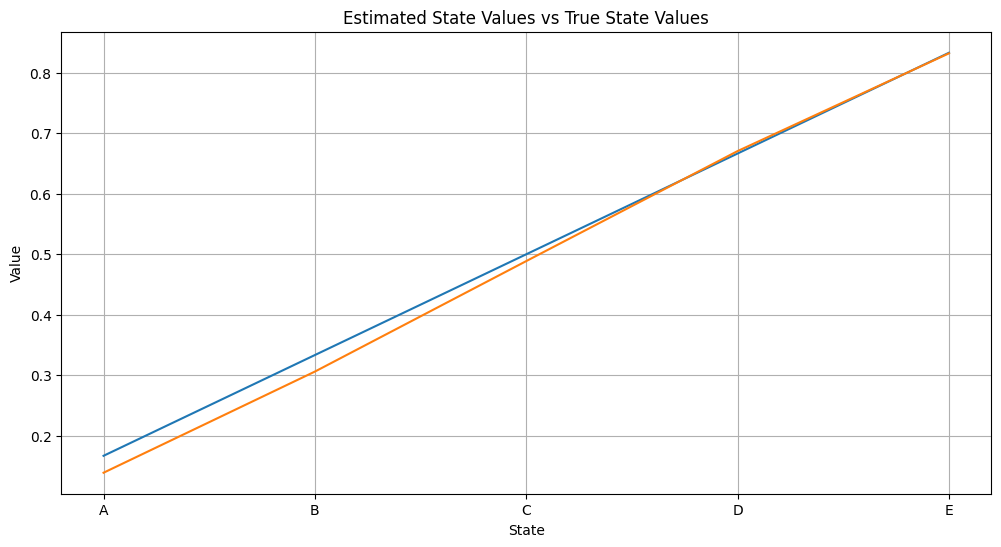

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

class RandomWalk:
    def __init__(self):
        """Initialize the 5-state Random Walk MRP."""
        self.states = ['A', 'B', 'C', 'D', 'E']
        self.terminal_states = ['left_terminal', 'right_terminal']

        self.state = '0'

        self.left_action_map = {
            'A': "left_terminal",
            'B': 'A',
            'C': 'B',
            'D': 'C',
            'E': 'D'
        }

        self.right_action_map = {
            'A': 'B',
            'B': 'C',
            'C': 'D',
            'D': 'E',
            'E': "right_terminal"
        }

    def reset(self):
        """Reset the environment to the start state (C)."""
        # pass  # TODO: Implement state reset

        self.state = 'C'
        reward = 0
        done = False
        return self.state, reward, done

    
    def step(self, action):
        """Take a step in the environment.
        
        Args:
            action (int): -1 for left, +1 for right.
        
        Returns:
            next_state (str): The next state.
            reward (float): Reward received.
            done (bool): Whether the episode has ended.
        """
        # pass  # TODO: Implement transition dynamics

        self.state = self.left_action_map[self.state] if action == -1 else self.right_action_map[self.state]
        reward = 1 if self.state == "right_terminal" else 0
        done = True if self.state in self.terminal_states else False

        return self.state, reward, done


class TDLearner:
    def __init__(self, alpha=0.1, state_space = None, gamma = None):
        """Initialize the TD(0) learning algorithm."""
        self.alpha = alpha
        self.gamma = 1 if gamma is None else gamma

        self.state_space = ["left_terminal", 'A', 'B', 'C', 'D', 'E', "right_terminal"] if state_space is None else state_space
        self.value_function = {s:0 for s in self.state_space}
    
    def update(self, state, reward, next_state):
        """Perform a TD(0) update step.
        
        Args:
            state (str): Current state.
            reward (float): Reward received.
            next_state (str): Next state after transition.
        """
        # pass  # Implement TD(0) update rule
        # print(f"{state},{next_state}")
        self.value_function[state] = self.value_function[state] + self.alpha*(reward + self.gamma*self.value_function[next_state] - self.value_function[state])



def run_experiment(num_episodes=1000,seed=2025):
    """Run the Random Walk experiment with TD(0)."""
    env = RandomWalk()
    agent = TDLearner(alpha=0.1)
    np.random.seed(seed)
    
    for episode in tqdm(range(num_episodes)):
        state,reward,done = env.reset()
        done = False
        while not done:
            action = np.random.choice([-1, 1])  # Random left or right move
            next_state, reward, done = env.step(action)
            agent.update(state, reward, next_state)
            state = next_state
    
    return agent.value_function  # Return learned values

def plot_results(estimated_values: dict):
    """Plot estimated values against true values."""
    
    true_values = {
        "left_terminal": 0, 
        'A': 1/6, 
        'B': 2/6, 
        'C': 3/6, 
        'D': 4/6, 
        'E': 5/6, 
        "right_terminal": 1
    }

    true_values.pop("left_terminal","default")
    true_values.pop("right_terminal","default")
    estimated_values.pop("left_terminal","default")
    estimated_values.pop("right_terminal","default")

    fig, axs = plt.subplots(1,1,figsize=(12,6)) # was 2,1
    # fig.suptitle("Estimated State Values vs True State Values")

    axs.plot(true_values.values())
    axs.plot(estimated_values.values())
    axs.grid("True")
    axs.set_title("Estimated State Values vs True State Values")
    axs.set_xticks(np.arange(len(estimated_values.keys())), labels=estimated_values.keys())
    axs.set_xlabel("State")
    axs.set_ylabel("Value")


    # im0 = axs[0].imshow(np.reshape(list(true_values.values()),(1,5)), cmap="YlGn", vmin=0, vmax=1)
    # axs[0].set_xticks(np.arange(len(true_values.keys())), labels=true_values.keys())
    # axs[0].set_yticks([], labels=[])
    # axs[0].set_title("True Values")

    # im1 = axs[1].imshow(np.reshape(list(estimated_values.values()),(1,5)), cmap="YlGn", vmin=0, vmax=1)
    # axs[1].set_xticks(np.arange(len(estimated_values.keys())), labels=estimated_values.keys())
    # axs[1].set_yticks([], labels=[])
    # axs[1].set_title("Estimated Values")
    # ax.set_ylabel("Player Sum")
    # ax.set_xlabel("Dealer Showing")

    # fig.colorbar(im0,label="State Value", orientation="vertical", location="right", ax=axs)
    # fig.tight_layout()
    plt.show()

if __name__ == "__main__":
    estimated_values = run_experiment()
    plot_results(estimated_values)

# Question 4 Windy Gridworld Domain

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [ ]:
class WindyGridWorld(object):
    def __init__(self, enable_king_move=False, enable_no_move=False):
        # define the grid space
        self.grid = np.zeros((7, 10))

        # define the state space
        self.state_space = [[r, c] for r, c in zip(np.where(self.grid == 0.0)[0],
                                                   np.where(self.grid == 0.0)[1])]

        # define the start state
        self.start_state = [3, 0]

        # define the goal state
        self.goal_state = [3, 7]

        # define the wind
        self.wind = np.array([0, 0, 0, 1, 1, 1, 2, 2, 1, 0], dtype=int)

        # define the action space
        self.action_space = {
            "up": np.array([-1, 0]),
            "down": np.array([1, 0]),
            "left": np.array([0, -1]),
            "right": np.array([0, 1])
        }
        
        # Enable King's moves (Comment out the above action space to create a new one for King's moves)
        # if enable_king_move:
            
        #     if enable_no_move:
        #         #TODO
        #     else:
        #         #TODO
        #
        # else:
        #     #TODO
            
                
        # track the current state, time step, and action
        self.state = None
        self.t = None
        self.act = None

    def reset(self):
        # reset the agent to the start state
        self.state = self.start_state
        # reset the time step tracker
        self.t = 0
        # reset the action tracker
        self.act = None
        # reset the terminal flag
        terminated = False
        return self.state, terminated

    def step(self, act):

        #TODO

        return self.state, reward, terminated

    def render(self):
        # plot the agent and the goal
        # agent = 1
        # goal = 2
        plot_arr = self.grid.copy()
        plot_arr[self.state[0], self.state[1]] = 1.0
        plot_arr[self.goal_state[0], self.goal_state[1]] = 2.0
        plt.clf()
        fig, arr = plt.subplots(1, 1)
        arr.set_title(f"state={self.state}, act={self.act}")
        arr.imshow(plot_arr)
        plt.show(block=False)
        plt.pause(1)
        plt.close(fig)


In [ ]:
class SARSA(object):
    def __init__(self, env, alpha, epsilon, gamma, timeout):
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space.keys())
        self.Q = np.zeros((self.state_num, self.action_num))

        # define the timeout
        self.timeout = timeout

    def behavior_policy(self, state):
        #TODO
        return None

    def update(self, s, a, r, s_prime, a_prime):
        #TODO
        return None

    def rollout(self):
        pass
        return None

    def run(self):
        #TODO
        return None

In [ ]:
class ExpectedSARSA(object):
    def __init__(self, env, alpha, epsilon, gamma, timeout):
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space.keys())
        self.Q = np.zeros((self.state_num, self.action_num))

        # define the timeout
        self.timeout = timeout

    def behavior_policy(self, state):
        #TODO
        return None

    def update(self, s, a, r, s_prime, a_prime):
        #TODO
        return None 
    
    def rollout(self):
        pass

    def run(self):
        #TODO
        return None

In [ ]:
class QLearning(object):
    def __init__(self, env, alpha, epsilon, gamma, timeout):
        # define the parameters
        self.alpha = alpha
        self.epsilon = epsilon
        self.gamma = gamma

        # environment
        self.env = env

        # define the Q value table
        self.state_num = len(self.env.state_space)
        self.action_num = len(self.env.action_space.keys())
        self.Q = np.zeros((self.state_num, self.action_num))

        # define the timeout
        self.timeout = timeout

    def behavior_policy(self, state):
        #TODO
        return None

    def update(self, s, a, r, s_prime):
        #TODO
        return None

    def rollout(self):
        pass

    def run(self):
        #TODO
        return None

In [3]:
def plot_curves(arr_list, legend_list, color_list, ylabel):
    """
    Args:
        arr_list (list): list of results arrays to plot
        legend_list (list): list of legends corresponding to each result array
        color_list (list): list of color corresponding to each result array
        ylabel (string): label of the Y axis

    Make sure the elements in the arr_list, legend_list, and color_list are associated with each other correctly.
    Do not forget to change the ylabel for different plots.
    """
    # Clear the current figure
    plt.clf()
    fig, ax = plt.subplots(figsize=(12, 8))

    # Set labels
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time Steps")

    # Plot results
    h_list = []
    for arr, legend, color in zip(arr_list, legend_list, color_list):
        # Compute the mean and standard error while ignoring NaN values
        mean_arr = np.nanmean(arr, axis=0)
        arr_err = np.nanstd(arr, axis=0) / np.sqrt(np.sum(~np.isnan(arr), axis=0))
        
        # Plot the mean
        h, = ax.plot(range(len(mean_arr)), mean_arr, color=color, label=legend)
        
        # Plot the confidence band
        arr_err = 1.96 * arr_err  # 95% confidence interval
        ax.fill_between(range(len(mean_arr)),
                        mean_arr - arr_err,
                        mean_arr + arr_err,
                        alpha=0.3, color=color)
        # Save the plot handle
        h_list.append(h)

    # Set the title (adjust as needed)
    ax.set_title("Windy Gridworld Results")
    ax.legend(handles=h_list)
    plt.show()

In [4]:
def run_on_policy_td_control(run_num, timeout):
    
    enable_king_move_actions = False
    enable_no_move_actions = False
    
    # create the environment
    env = WindyGridWorld(enable_king_move=enable_king_move_actions, enable_no_move=enable_no_move_actions)

    # parameters
    epsilon = 0.1
    alpha = 0.5
    gamma = 1.0

    # create the expected SARSA
    expected_sarsa_results_list = []
    for _ in range(run_num):
        # run for each trial
        controller_expected_sarsa = ExpectedSARSA(env, alpha, epsilon, gamma, timeout)
        episodes = controller_expected_sarsa.run()
        # append the results
        expected_sarsa_results_list.append(episodes[0:8000])
        
    # create the SARSA
    sarsa_results_list = []
    for _ in range(run_num):
        # run for each trial
        controller_sarsa = SARSA(env, alpha, epsilon, gamma, timeout)
        episodes = controller_sarsa.run()
        # append the results
        sarsa_results_list.append(episodes[0:8000])

    # create the Q learning
    q_learning_results_list = []
    for _ in range(run_num):
        # run for each trial
        controller_q_learning = QLearning(env, alpha, epsilon, gamma, timeout)
        episodes = controller_q_learning.run()
        # append the results
        q_learning_results_list.append(episodes[0:8000])
    
    sarsa_array = np.array(sarsa_results_list)
    expected_sarsa_array = np.array(expected_sarsa_results_list)
    q_learning_array = np.array(q_learning_results_list)
    
    # Plot the results
    plot_curves(
        [sarsa_array, expected_sarsa_array, q_learning_array],
        ['SARSA', 'Expected SARSA', 'Q-learning'],
        ['r', 'b', 'g'],
        "Episodes"
    )

In [ ]:
if __name__ == "__main__":
    # set randomness
    np.random.seed(1234)
    random.seed(1234)

    # trial number
    trial_num = 10
    # maximal time steps
    max_time_steps = 8000
    
    
    # run SARSA and Q Learning
    run_on_policy_td_control(trial_num, max_time_steps)

# Question 4
- Please refer to starter code from question 4 to help you get started. You will create your own TD(0) and Monte Carlo classes.
- We will continue with the original windy gridworld domain. 
- A fixed policy π will be specified to collect episodes.
- A certain number of “training” episodes N ∈ {1, 10, 50} will be collected.
- Each method being investigated ( On-policy TD(0), On-policy Monte-Carlo prediction) will learn to      estimate the state-value.
function using the N “training“ episodes, respectively.
- We then evaluate the distribution of learning targets each method experiences at a specified state S. In
this question, S is the initial state marked as S in the Example 6.5.
- To do so, you need to collect additional 100 “evaluation” episodes. Instead of using these to perform
further updates to the state-value function, we will instead evaluate the distribution of learning targets
V(S) based on the “evaluation” episodes. For example, TD(0) will experience a set of {R+ V(S′)} targets,
whereas Monte-Carlo will experience a set of {G} targets.
- Note that in practice you should pre-collect both the training and evaluation episodes for efficiency and to
ensure consistency while comparing between different methods.

In [ ]:
def run_on_policy_mc_td_epsilon_greedy_windy_gridworld():
    enable_king_move_actions = False
    enable_no_move_actions = False
    
    # create environments
    env = WindyGridWorld(enable_king_move=enable_king_move_actions,
                         enable_no_move=enable_no_move_actions)
    env.reset()

    #TODO

In [ ]:
if __name__ == "__main__":
    np.random.seed(1234)
    random.seed(1234)
    run_on_policy_mc_td_epsilon_greedy_windy_gridworld()